In [86]:
import pandas as pd
from ucimlrepo import fetch_ucirepo
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

## Wczytanie zbioru IRIS
Dane dzielimy na:
- **X_iris** – cechy (długość/szerokość działki i płatka)
- **y_iris** – etykiety klas (gatunek irysa)

In [87]:
iris_repo = fetch_ucirepo(id=53)

X_iris = iris_repo.data.features
y_iris = iris_repo.data.targets

df_iris = pd.concat([X_iris, y_iris], axis=1)
df_iris.head()

,sepal length,sepal width,petal length,petal width,class
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa


## Analiza zbioru i wizualizacja rozkładu danych
Sprawdzamy rozmiar zbioru oraz podstawowe statystyki opisowe:

In [88]:
print(f"Number of rows: {len(df_iris)}")
print(f"Number of attributes: {len(X_iris.columns)}")
print(f"\nStatistics:")
print(df_iris.describe())

Number of rows: 150
Number of attributes: 4

Statistics:
       sepal length  sepal width  petal length  petal width
count    150.000000   150.000000    150.000000   150.000000
mean       5.843333     3.054000      3.758667     1.198667
std        0.828066     0.433594      1.764420     0.763161
min        4.300000     2.000000      1.000000     0.100000
25%        5.100000     2.800000      1.600000     0.300000
50%        5.800000     3.000000      4.350000     1.300000
75%        6.400000     3.300000      5.100000     1.800000
max        7.900000     4.400000      6.900000     2.500000


Zbiór zawiera **150 próbek** opisanych **4 cechami** numerycznymi 

### Obserwacje:

- **Sepal length** – działki kielicha są dość podobnej długości u wszystkich irysów, różnice między nimi nie są duże

- **Sepal width** – to najbardziej „spokojna” cecha w tym zbiorze. U większości irysów szerokość kielicha ma podobną wartość, niezależnie od gatunku.

- **Petal length** – płatki jednych irysów są drastycznie dłuższe od innych, co sugeruje że gatunek mocno wpływa na tę cechę

- **Petal width** – szerokość płatka bardzo różni się między kwiatami, prawdopodobnie właśnie dlatego że należą do różnych gatunków

Classes: <StringArray>
['Iris-setosa', 'Iris-versicolor', 'Iris-virginica']
Length: 3, dtype: str

Class distribution:
class
Iris-setosa        50
Iris-versicolor    50
Iris-virginica     50
Name: count, dtype: int64


/var/folders/69/3bgwy7vx3g9g3hc8fwyj9pfh0000gn/T/ipykernel_58724/1054882043.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_iris, x='class', palette='Set1')


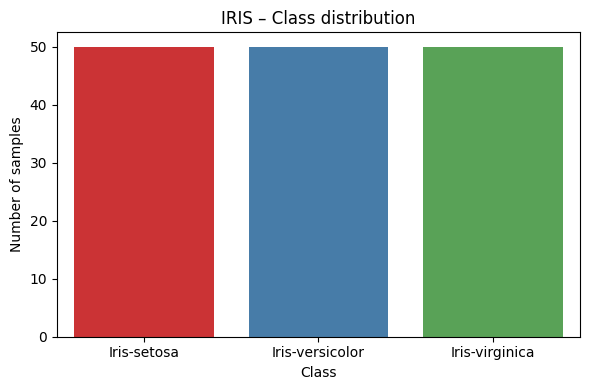

In [89]:
print(f"Classes: {df_iris['class'].unique()}")
print(f"\nClass distribution:")
print(df_iris['class'].value_counts())


plt.figure(figsize=(6, 4))
sns.countplot(data=df_iris, x='class', palette='Set1')
plt.title('IRIS – Class distribution')
plt.xlabel('Class')
plt.ylabel('Number of samples')
plt.tight_layout()
plt.show()

Zbiór IRIS zawiera **3 gatunki** irysów:
- *Iris-setosa*
- *Iris-versicolor*
- *Iris-virginica*

Każdy gatunek reprezentowany jest przez dokładnie **50 próbek** 

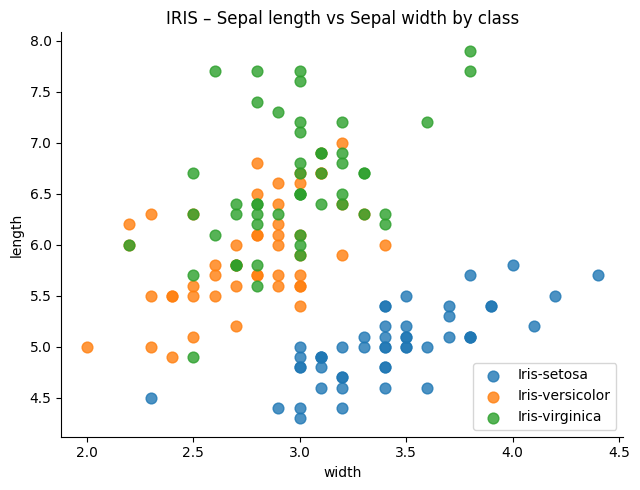

In [90]:
sns.lmplot(
    data=df_iris,
    x='sepal width',
    y='sepal length',
    hue='class',
    height=5,
    aspect=1.3,
    fit_reg=False,
    scatter_kws={'s': 60},
    legend=False
)
plt.legend(
    loc='lower right', 
    title=None
)

plt.title('IRIS – Sepal length vs Sepal width by class')
plt.xlabel('width')
plt.ylabel('length')


plt.tight_layout()
plt.show()

- **Iris-setosa** – wyraźnie oddziela się od reszty, skupiona po prawej stronie
  wykresu (szeroka działka przy stosunkowo małej długości)

- **Iris-versicolor** i **Iris-virginica** – mocno **nakładają się
  na siebie** w środkowej części wykresu, co oznacza że sama działka kielicha
  nie wystarczy do ich rozróżnienia. Dla **Iris-virginica** działka jest zwykle dłuższa, ale zdarzają się wyjątki.

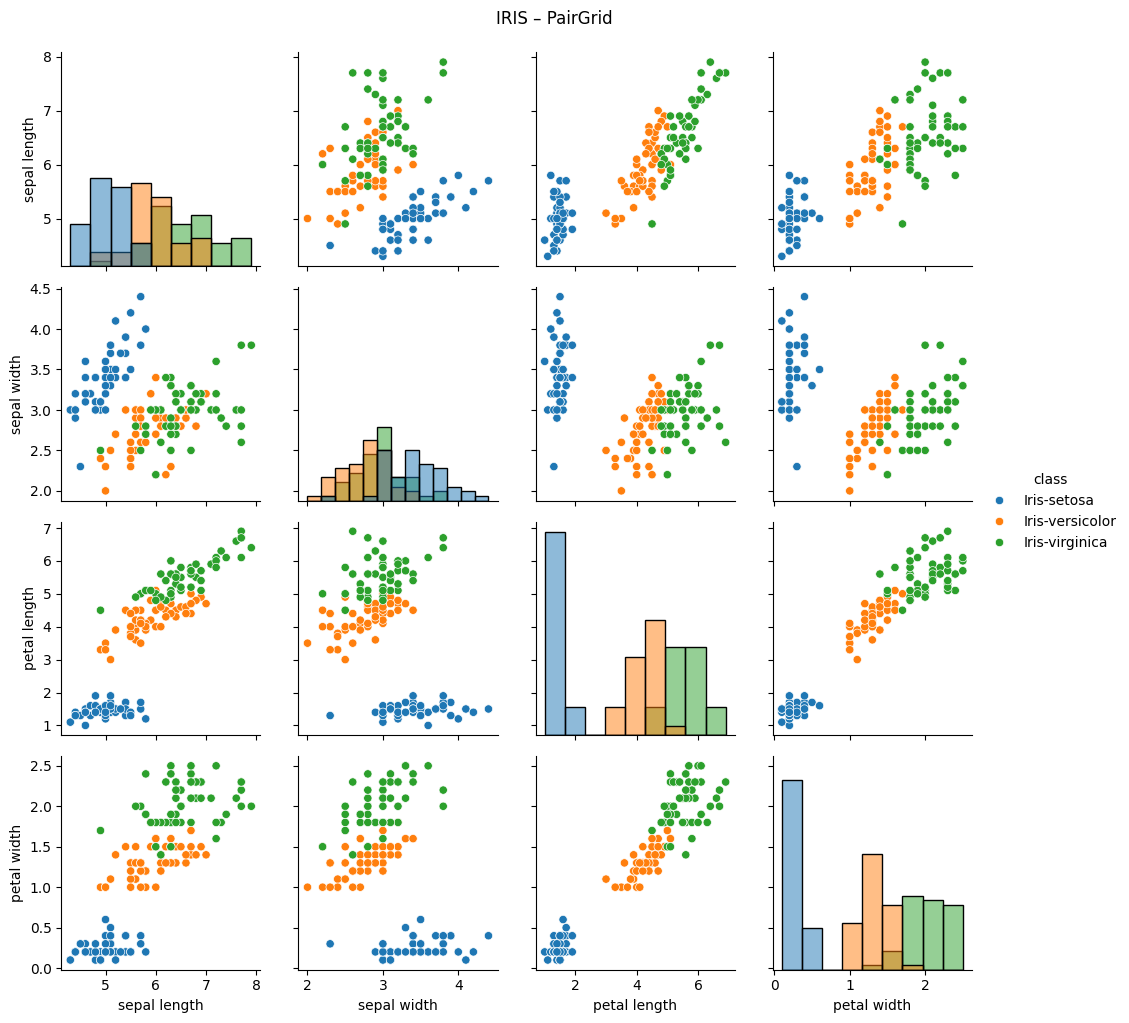

In [91]:
g = sns.PairGrid(df_iris, hue='class')
g.map_diag(sns.histplot)
g.map_offdiag(sns.scatterplot)  
g.add_legend()
plt.suptitle('IRIS – PairGrid', y=1.02)
plt.show()

### rozkłady pojedynczych cech

- **sepal length** – trzy gatunki nachodzą na siebie, słabo rozdziela klasy
- **sepal width** – podobnie, wszystkie trzy "górki" są w tym samym miejscu (~2.5–3.5 cm), 
  praktycznie nieużyteczna cecha do rozróżniania gatunków
- **petal length** – setosa tworzy osobną górkę przy ~1.5 cm, versicolor i virginica 
  są dalej ale trochę się nakładają – dobra cecha
- **petal width** – najczyściejszy podział, setosa skrajnie po lewej (~0.2 cm), 
  versicolor i virginica wyraźnie przesunięte w prawo i między sobą też widać różnicę


### Setosa– zawsze osobno

Na **każdym** wykresie setosa tworzy zwarte, izolowane skupisko.
Niezależnie jaką parę cech weźmiesz – setosa jest łatwa do odróżnienia od pozostałych.
To najłatwiejsza klasa do klasyfikacji w tym zbiorze.


### Versicolor vs Virginica

- Przy cechach działki (sepal length, sepal width) oba gatunki **silnie się nakładają** –
  nie da się ich rozdzielić
- Przy cechach płatka (petal length, petal width) widać już wyraźne przesunięcie –
  virginica ma dłuższe i szersze płatki niż versicolor, ale **granica między nimi nie jest ostra**,
  zawsze jest strefa gdzie punkty się mieszają


## Użycie PCA 

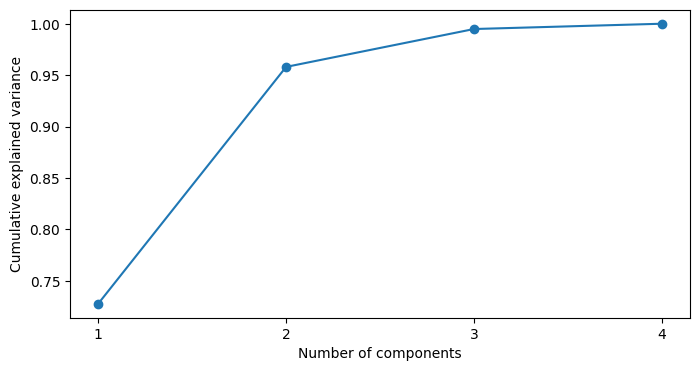

In [92]:
scaler = StandardScaler()
X_iris_scaled = scaler.fit_transform(X_iris)

pca_full = PCA()
pca_full.fit(X_iris_scaled)

plt.figure(figsize=(8, 4))
plt.plot(range(1, len(pca_full.explained_variance_ratio_)+1), 
         pca_full.explained_variance_ratio_.cumsum(), 
         marker='o')
plt.xlabel('Number of components')
plt.ylabel('Cumulative explained variance')
plt.xticks(range(1, len(pca_full.explained_variance_ratio_)+1))
plt.show()

Już **2 składowe** zachowują ok.96% całej informacji ze zbioru, czyli z 4 wymiarów możemy zejść do 2 tracąc zaledwie 4% danych.
Wykres "wypłaszcza się" po 2. składowej to sygnał że dalsze składowe wnoszą już bardzo mało i można je pominąć.

In [93]:
pca = PCA(n_components=2)
X_iris_pca = pca.fit_transform(X_iris_scaled)

print(f"PC1 explains: {pca.explained_variance_ratio_[0]:.2%} of variance")
print(f"PC2 explains: {pca.explained_variance_ratio_[1]:.2%} of variance")
print(f"Total: {sum(pca.explained_variance_ratio_):.2%} of variance kept")

components_df = pd.DataFrame(
    pca.components_,
    columns=X_iris.columns,
    index=['PC1', 'PC2']
)
print(components_df)

PC1 explains: 72.77% of variance
PC2 explains: 23.03% of variance
Total: 95.80% of variance kept
     sepal length  sepal width  petal length  petal width
PC1      0.522372    -0.263355      0.581254     0.565611
PC2      0.372318     0.925556      0.021095     0.065416


**PC1** zachowuje 72.77% informacji i składa się głównie z cech płatka
(petal length, petal width) oraz sepal length.

**PC2** zachowuje 23.03% informacji i składa się niemal wyłącznie z sepal width.

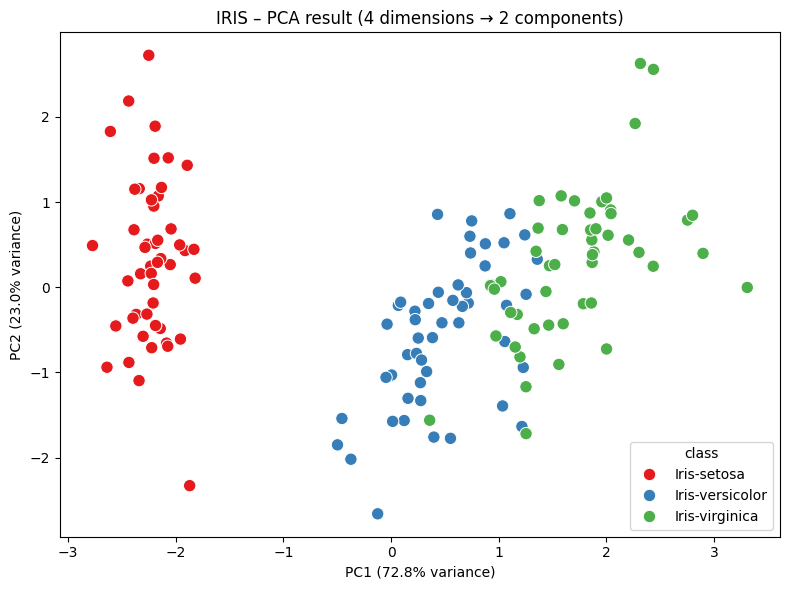

In [94]:
df_pca = pd.DataFrame(X_iris_pca, columns=['PC1', 'PC2'])
df_pca['class'] = y_iris.values.ravel()
plt.figure(figsize=(8, 6))
sns.scatterplot(
    data=df_pca,
    x='PC1',
    y='PC2',
    hue='class',
    palette='Set1',
    s=80
)
plt.title('IRIS – PCA result (4 dimensions → 2 components)')
plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]:.1%} variance)")
plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]:.1%} variance)")
plt.tight_layout()
plt.show()

- Oś PC1 wyraźnie rozdziela setosę od reszty, co potwierdza że
to cechy płatka (dominujące w PC1) są kluczowe dla klasyfikacji.
- Oś PC2 dodatkowo rozciąga chmurę w pionie ale nie poprawia
znacząco separacji między versicolor a virginica.

## Wczytanie zbioru GLASS
Dane dzielimy na:
- **X_glass** – cechy (zawartość różnych pierwiastków w szkle)
- **y_glass** – etykiety klas (typ szkła)

In [95]:
glass_repo = fetch_ucirepo(id=42)

X_glass = glass_repo.data.features
y_glass = glass_repo.data.targets

df_glass = pd.concat([X_glass, y_glass], axis=1)
df_glass.head()

,RI,Na,Mg,Al,Si,K,Ca,Ba,Fe,Type_of_glass
0,1.52101,13.64,4.49,1.10,71.78,0.06,8.75,0.0,0.0,1
1,1.51761,13.89,3.60,1.36,72.73,0.48,7.83,0.0,0.0,1
2,1.51618,13.53,3.55,1.54,72.99,0.39,7.78,0.0,0.0,1
3,1.51766,13.21,3.69,1.29,72.61,0.57,8.22,0.0,0.0,1
4,1.51742,13.27,3.62,1.24,73.08,0.55,8.07,0.0,0.0,1


## Analiza zbioru i wizualizacja rozkładu danych
Sprawdzamy rozmiar zbioru oraz podstawowe statystyki opisowe:

In [96]:
print(f"Number of rows: {len(df_glass)}")
print(f"Number of attributes: {len(X_glass.columns)}")
print(f"\nStatistics:")
print(df_glass.describe())

Number of rows: 214
Number of attributes: 9

Statistics:
               RI          Na          Mg          Al          Si           K  \
count  214.000000  214.000000  214.000000  214.000000  214.000000  214.000000   
mean     1.518365   13.407850    2.684533    1.444907   72.650935    0.497056   
std      0.003037    0.816604    1.442408    0.499270    0.774546    0.652192   
min      1.511150   10.730000    0.000000    0.290000   69.810000    0.000000   
25%      1.516522   12.907500    2.115000    1.190000   72.280000    0.122500   
50%      1.517680   13.300000    3.480000    1.360000   72.790000    0.555000   
75%      1.519157   13.825000    3.600000    1.630000   73.087500    0.610000   
max      1.533930   17.380000    4.490000    3.500000   75.410000    6.210000   

               Ca          Ba          Fe  Type_of_glass  
count  214.000000  214.000000  214.000000     214.000000  
mean     8.956963    0.175047    0.057009       2.780374  
std      1.423153    0.497219    0.0

Zbiór **GLASS** zawiera **214 próbek** opisanych **9 cechami** chemicznymi składu szkła.

- **RI** (współczynnik refrakcji) – bardzo małe odchylenie std (0.003), wszystkie próbki
  mieszczą się w wąskim przedziale 1.511–1.534, praktycznie jednakowy dla wszystkich szkieł

- **Na** (sód) – druga najliczniejsza składowa (~13.4%), umiarkowany rozrzut,
  może pomagać w rozróżnianiu typów szkła

- **Mg** (magnez) – duże odchylenie std (1.44) względem średniej (2.68),
  minimum wynosi 0 – niektóre typy szkła w ogóle nie zawierają magnezu

- **Si** (krzem) – dominuje składem, średnio aż ~72.6%, mały rozrzut – krzem jest
  głównym składnikiem każdego szkła, mało zróżnicowany między typami

- **K** (potas) i **Al** (aluminium) – umiarkowany rozrzut, mogą nieść
  dodatkową informację o typie szkła

- **Ca** (wapń) – średnio ~9% składu, umiarkowany rozrzut, ale maksimum sięga aż 16.19% – niektóre typy szkła zawierają znacznie więcej wapnia niż przeciętnie

- **Ba** (bar) i **Fe** (żelazo) – mediana wynosi **0** dla obu,
  czyli większość próbek nie zawiera tych pierwiastków wcale –
  ale gdy już się pojawiają, mogą być silnym sygnałem konkretnego typu szkła




Classes: [1 2 3 5 6 7]

Class distribution:
Type_of_glass
2    76
1    70
7    29
3    17
5    13
6     9
Name: count, dtype: int64


/var/folders/69/3bgwy7vx3g9g3hc8fwyj9pfh0000gn/T/ipykernel_58724/23910101.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_glass, x='Type_of_glass', palette='Set1')


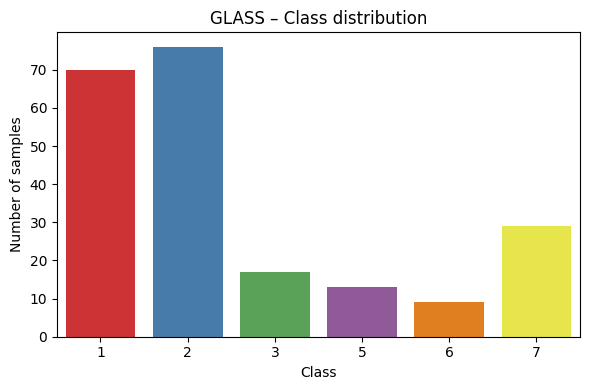

In [97]:
print(f"Classes: {df_glass['Type_of_glass'].unique()}")
print(f"\nClass distribution:")
print(df_glass['Type_of_glass'].value_counts())

plt.figure(figsize=(6, 4))
sns.countplot(data=df_glass, x='Type_of_glass', palette='Set1')
plt.title('GLASS – Class distribution')
plt.xlabel('Class')
plt.ylabel('Number of samples')
plt.tight_layout()
plt.show()

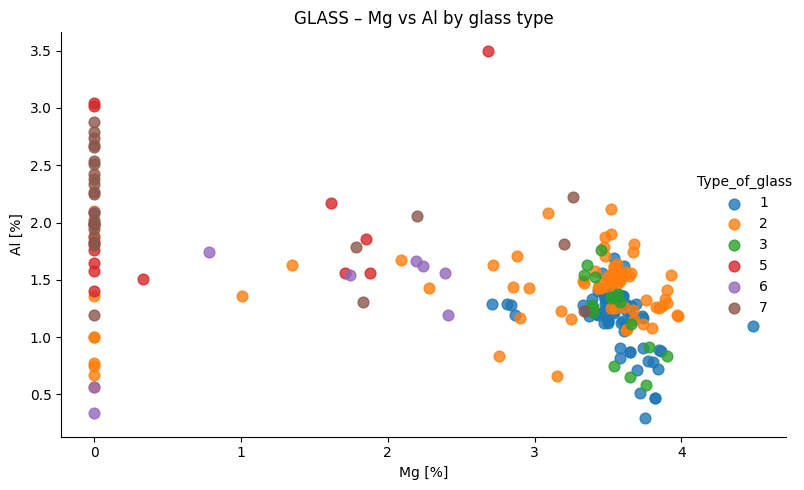

In [98]:
sns.lmplot(
    data=df_glass,
    x='Mg',
    y='Al',
    hue='Type_of_glass',
    height=5,
    aspect=1.4,
    fit_reg=False,
    scatter_kws={'s': 60}
)
plt.title('GLASS – Mg vs Al by glass type')
plt.xlabel('Mg [%]')
plt.ylabel('Al [%]')
plt.tight_layout()
plt.show()

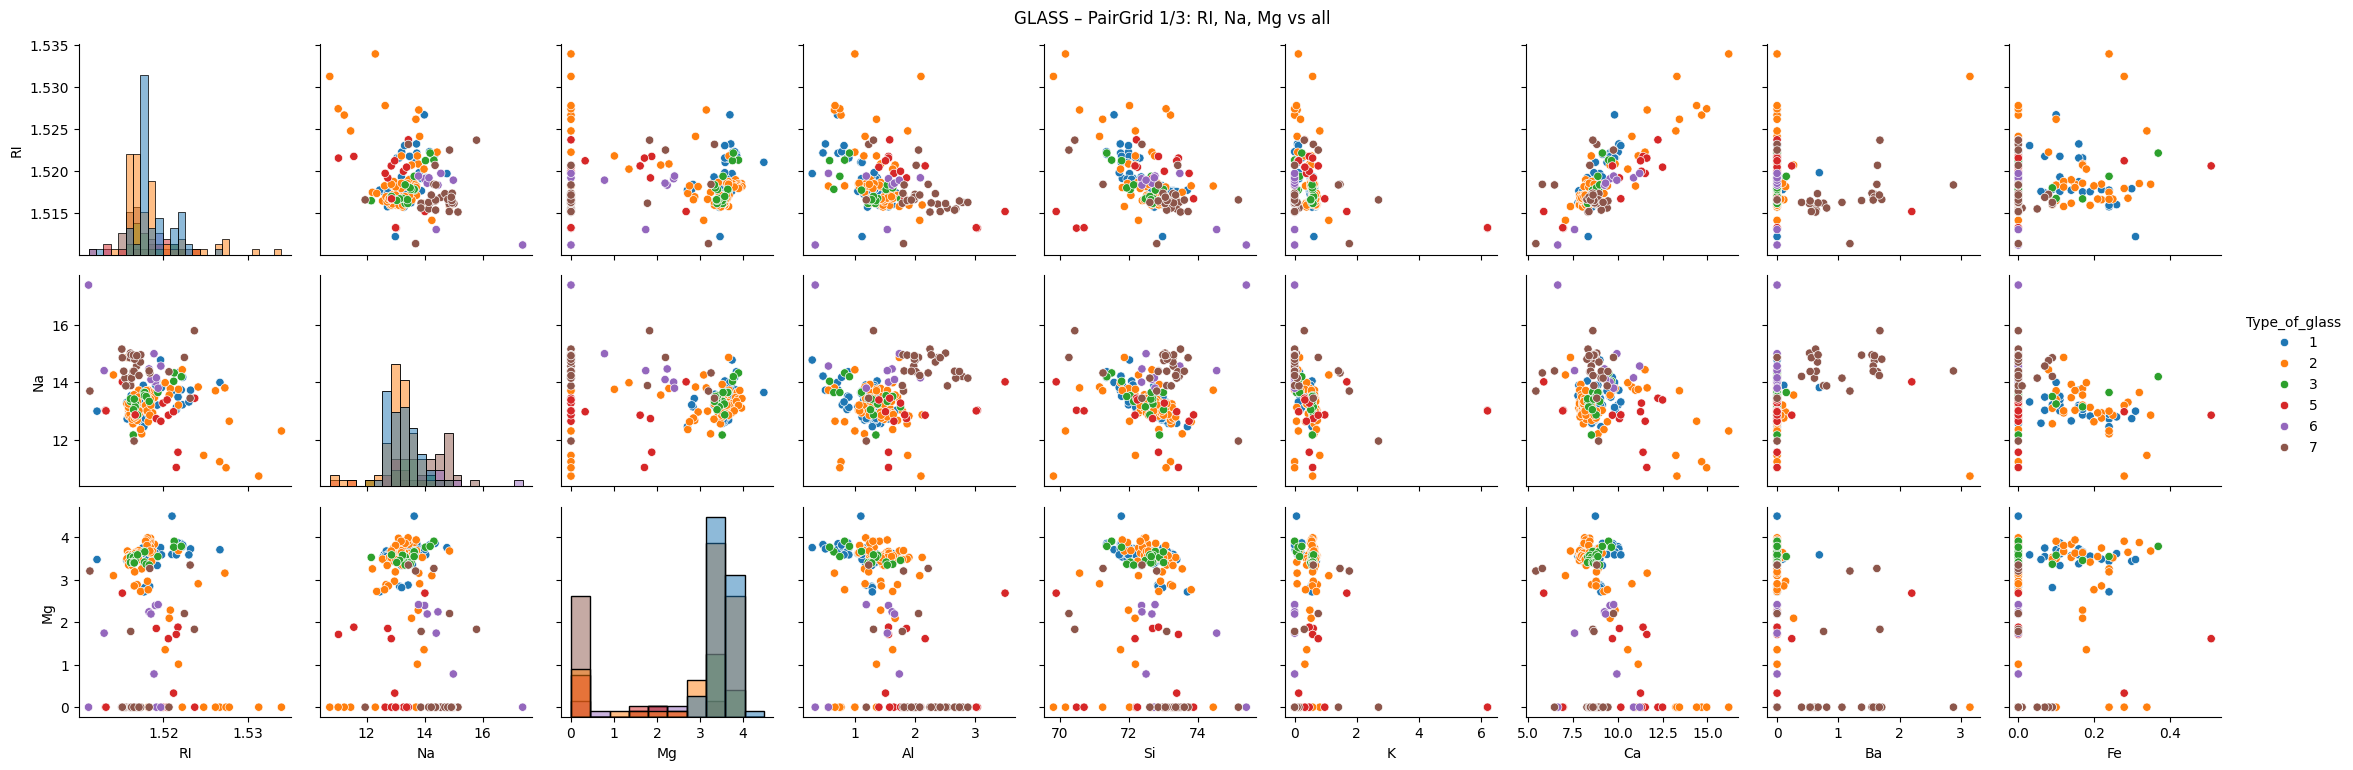

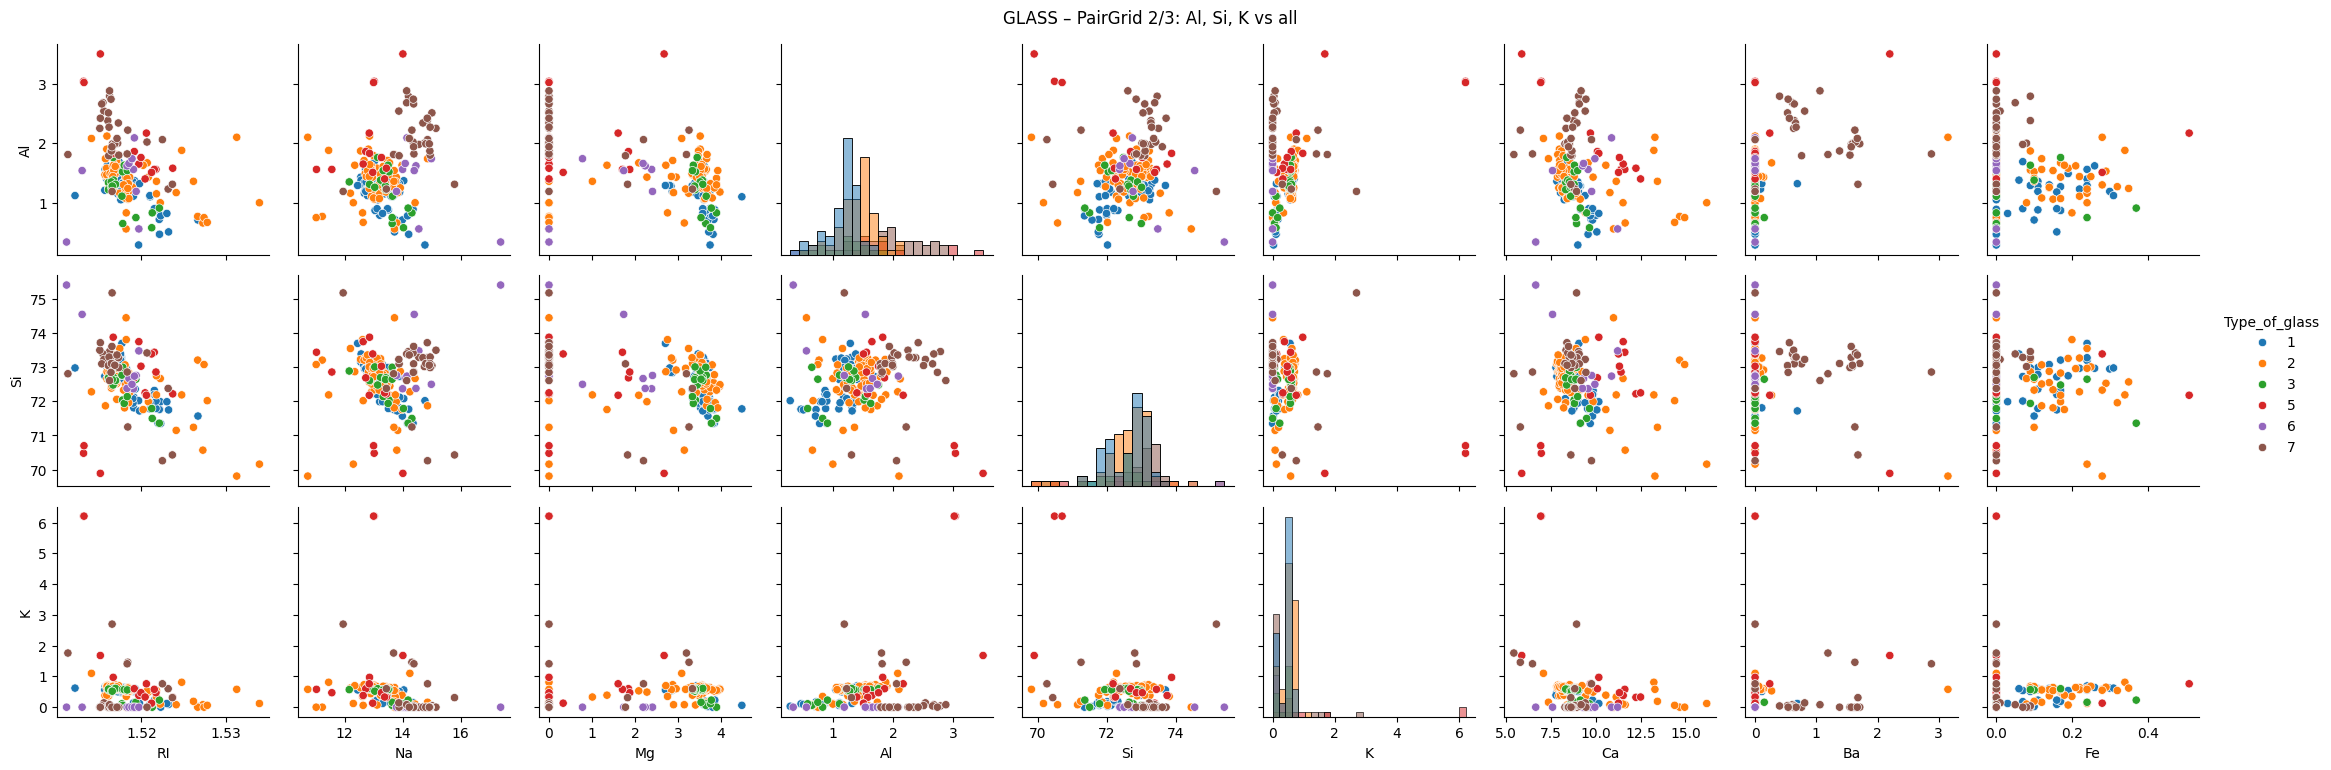

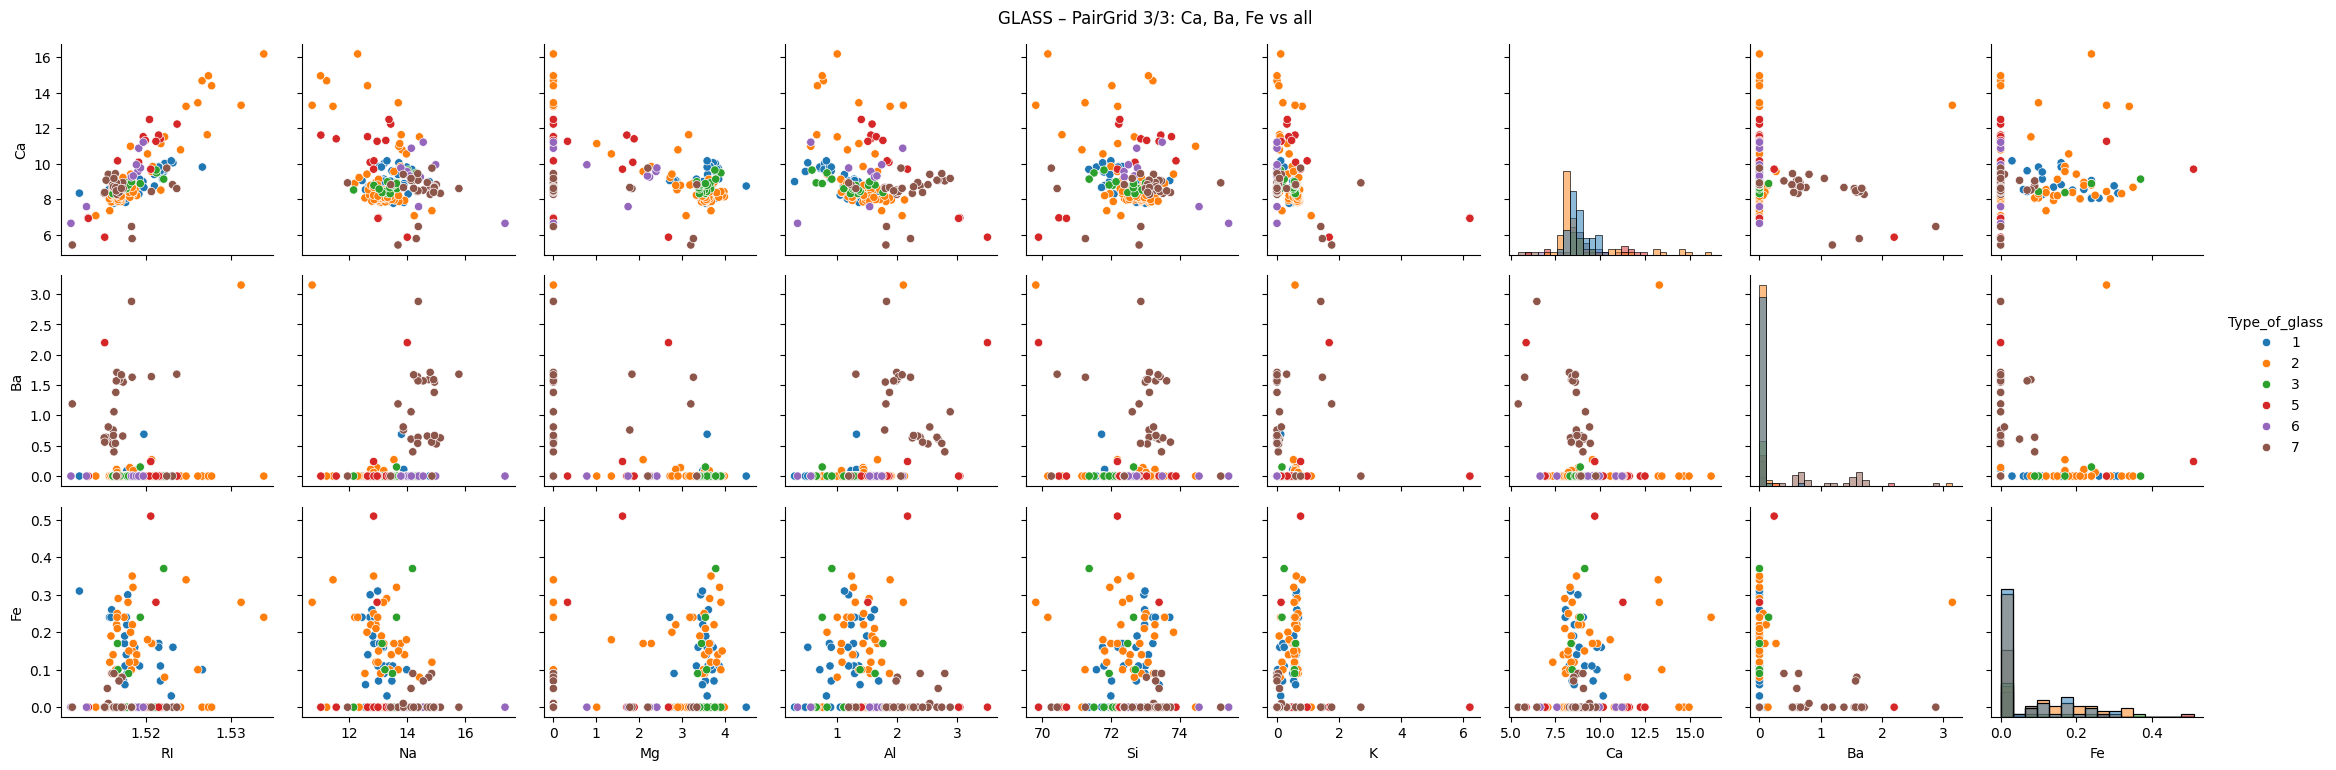

In [99]:
all_attrs = ['RI', 'Na', 'Mg', 'Al', 'Si', 'K', 'Ca', 'Ba', 'Fe']

for i in range(0, len(all_attrs), 3):
    group = all_attrs[i:i+3]
    g = sns.PairGrid(df_glass, hue='Type_of_glass',
                     x_vars=all_attrs,
                     y_vars=group,
                     palette='tab10')
    g.map_diag(sns.histplot)
    g.map_offdiag(sns.scatterplot)
    g.add_legend()
    plt.suptitle(f'GLASS – PairGrid {i//3+1}/3: {", ".join(group)} vs all', y=1.02)
    plt.show()

/var/folders/69/3bgwy7vx3g9g3hc8fwyj9pfh0000gn/T/ipykernel_58724/2603763481.py:14: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


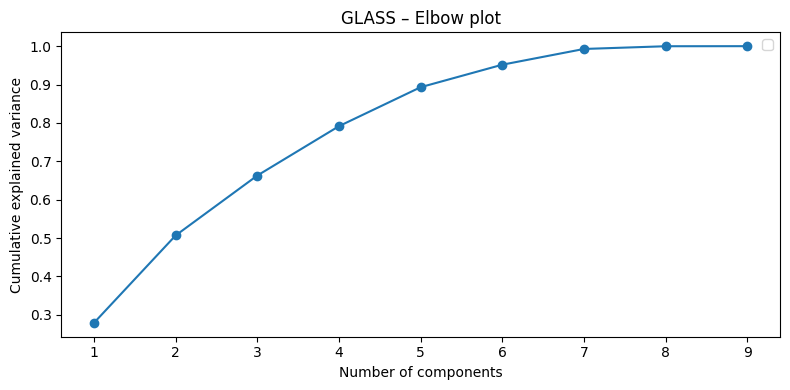

In [100]:

scaler_glass = StandardScaler()
X_glass_scaled = scaler_glass.fit_transform(X_glass)

pca_full = PCA()
pca_full.fit(X_glass_scaled)

plt.figure(figsize=(8, 4))
plt.plot(range(1, len(pca_full.explained_variance_ratio_)+1), 
         pca_full.explained_variance_ratio_.cumsum(), 
         marker='o')
plt.xlabel('Number of components')
plt.ylabel('Cumulative explained variance')
plt.title('GLASS – Elbow plot')
plt.legend()
plt.tight_layout()
plt.show()

PC1 explains: 27.90% of variance
PC2 explains: 22.78% of variance
Total: 50.68% of variance kept


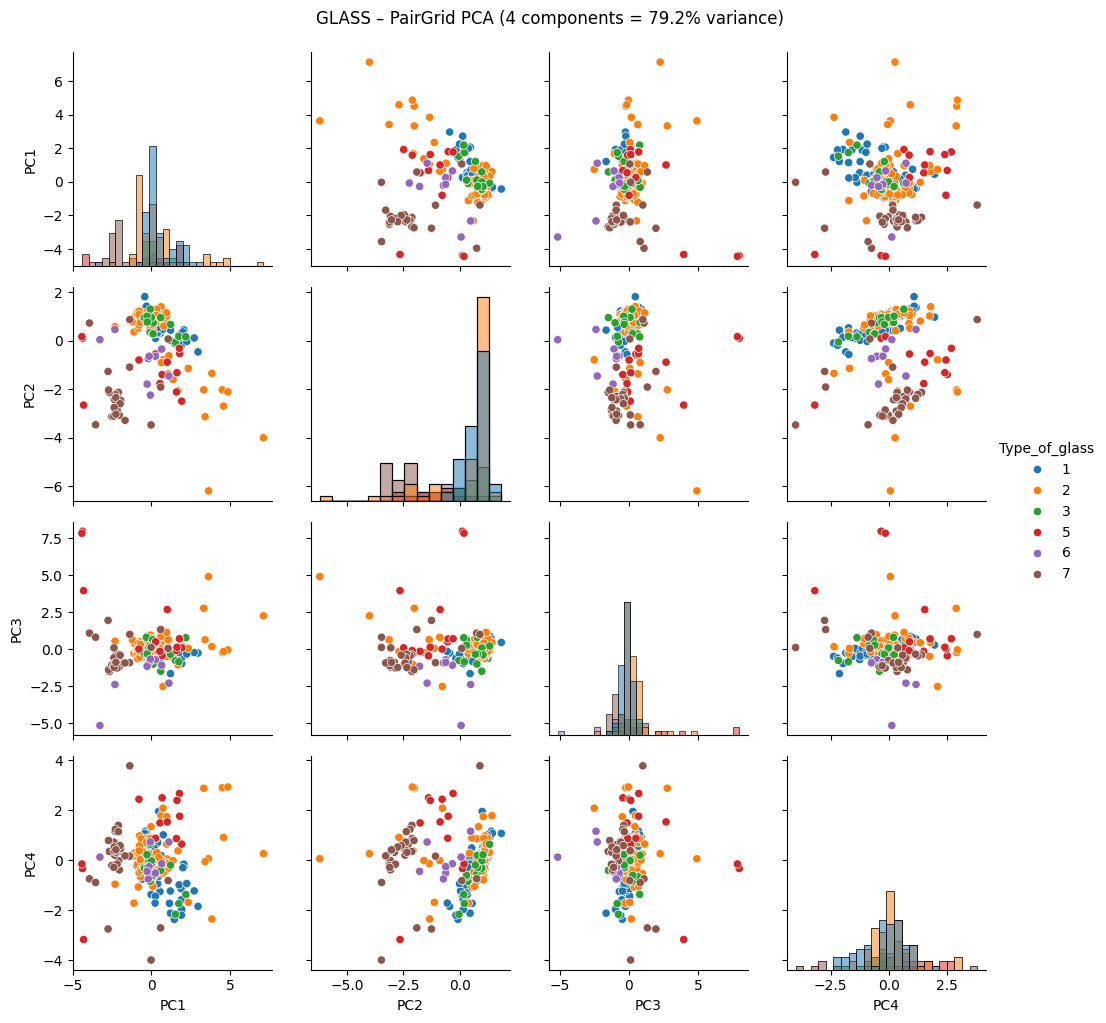

In [104]:
# 2. PCA – redukujemy 9 wymiarów do 2
pca_glass = PCA(n_components=2)
X_glass_pca = pca_glass.fit_transform(X_glass_scaled)

print(f"PC1 explains: {pca_glass.explained_variance_ratio_[0]:.2%} of variance")
print(f"PC2 explains: {pca_glass.explained_variance_ratio_[1]:.2%} of variance")
print(f"Total: {sum(pca_glass.explained_variance_ratio_):.2%} of variance kept")

pca_glass4 = PCA(n_components=4)
X_glass_pca4 = pca_glass4.fit_transform(X_glass_scaled)

df_pca_glass4 = pd.DataFrame(X_glass_pca4, columns=['PC1', 'PC2', 'PC3', 'PC4'])
df_pca_glass4['Type_of_glass'] = y_glass.values.ravel()

g = sns.PairGrid(df_pca_glass4, hue='Type_of_glass', 
                 vars=['PC1', 'PC2', 'PC3', 'PC4'], palette='tab10')
g.map_diag(sns.histplot)
g.map_offdiag(sns.scatterplot)
g.add_legend()
plt.suptitle(f'GLASS – PairGrid PCA (4 components = {sum(pca_glass4.explained_variance_ratio_):.1%} variance)', y=1.02)
plt.show()